In [37]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import os
sns.set(style="whitegrid")
sns.set_context("paper", font_scale=0.5)
plt.rcParams["font.family"] = "serif"


### RQ: How does summarization quality vary across combinations of programming languages and natural languages?

#### Goal:

* Compare metrics like BLEU, ROUGE-L, BERTScore, etc., across different programming languages (Python, Java, etc.) and natural languages (English, French, etc.).

* Identify interesting patterns (e.g., which PL × NL pairs are harder to summarize).

* Visualize results clearly.
    

In [38]:
%pwd

'C:\\Users\\emann\\Documents\\GitHub\\CodeClarity'

In [40]:
df = pd.read_csv('data/evalScores0.5.csv')
df.head()

,sample_id,model_name,programming_language,length_bucket,bt_language,reference_summary,generated_summary,backtranslated_summary,bertscore_precision,bertscore_recall,bertscore_f1,bleu,chrf++,rougeL,meteor,comet,side,prompt_used
0,sample_68262,codegemma-7b-it,go,short,chinese,## Code Summary:\n\n**Function:** Use\n\n**Pur...,**函数名称：** Use\n\n**函数用途：** 将给定的路由处理器添加到 Handle...,**Function Name:** Use\n\n**Function Purpose:*...,0.9173,0.9130,0.9151,0.328843,0.479059,0.377358,0.525757,0.793025,0.951876,0
1,sample_59144,codegemma-7b-it,go,short,chinese,## Function Summary: Config()\n\n**Purpose:** ...,## 代码摘要\n\n**函数名:** Config\n\n**函数用途:** 获取节点配置...,## Code Summary\n\n**Function Name:** Config\n...,0.9310,0.9239,0.9274,0.365100,0.524844,0.426540,0.463868,0.855142,0.783150,0
2,sample_56854,codegemma-7b-it,go,short,chinese,**Function Name:** LogField\n\n**Purpose:** Th...,## 代码摘要\n\n**函数名:** LogField\n\n**函数用途:** 将键值对...,## Code Summary\n\n**Function Name:** LogField...,0.8747,0.8992,0.8868,0.142393,0.376426,0.315789,0.370370,0.770519,0.803816,0
3,sample_63319,codegemma-7b-it,go,short,chinese,**Function:** UnmarshalJSON\n\n**Purpose:** To...,**函数名称:** UnmarshalJSON\n\n**函数用途:** 解码 JSON 数...,**Function Name:** UnmarshalJSON\n\n**Function...,0.9365,0.9438,0.9401,0.346042,0.679673,0.731707,0.812673,0.819250,0.926977,0
4,sample_62492,codegemma-7b-it,go,short,chinese,## Code Summary:\n\n**Function:** Less\n\n**Pu...,**函数名：** Less\n\n**函数用途：** 比较两个 Peer 对象的名称，并按名...,**Function Name:** Less\n\n**Function Purpose:...,0.9042,0.8949,0.8996,0.137140,0.345504,0.390698,0.336803,0.763346,0.545070,0


In [41]:
df.columns

Index(['sample_id', 'model_name', 'programming_language', 'length_bucket',
       'bt_language', 'reference_summary', 'generated_summary',
       'backtranslated_summary', 'bertscore_precision', 'bertscore_recall',
       'bertscore_f1', 'bleu', 'chrf++', 'rougeL', 'meteor', 'comet', 'side',
       'prompt_used'],
      dtype='object')

In [42]:

metrics = ['bertscore_precision', 'bertscore_recall', 'bertscore_f1', 'bleu', 'chrf++', 'rougeL', 'meteor', 'comet', 'side']

avg_scores = df.groupby(['bt_language', 'length_bucket'])[metrics].mean().reset_index()
avg_scores

,bt_language,length_bucket,bertscore_precision,bertscore_recall,bertscore_f1,bleu,chrf++,rougeL,meteor,comet,side
0,arabic,long,0.899797,0.884127,0.891739,0.135603,0.357799,0.337492,0.310192,0.752735,0.857965
1,arabic,medium,0.906964,0.891892,0.899266,0.142855,0.381140,0.361973,0.338208,0.754294,0.888113
2,arabic,short,0.908851,0.897824,0.903207,0.155716,0.393787,0.373219,0.353483,0.752909,0.850602
3,chinese,long,0.906365,0.905995,0.906086,0.215631,0.474550,0.442488,0.429286,0.809728,0.887648
4,chinese,medium,0.913947,0.913444,0.913607,0.226872,0.487169,0.473378,0.454852,0.800345,0.913165
5,chinese,short,0.916853,0.917375,0.917010,0.237174,0.494942,0.484633,0.471941,0.793004,0.868595
6,french,long,0.912971,0.900201,0.906435,0.203796,0.456032,0.422731,0.386887,0.798556,0.892609
7,french,medium,0.917473,0.902069,0.909599,0.192983,0.444901,0.442355,0.385205,0.778973,0.927575
8,french,short,0.918162,0.902396,0.910092,0.187493,0.436778,0.432035,0.378029,0.767083,0.887889
9,hindi,long,0.890662,0.881666,0.885962,0.138548,0.338977,0.325195,0.302895,0.727555,0.815185


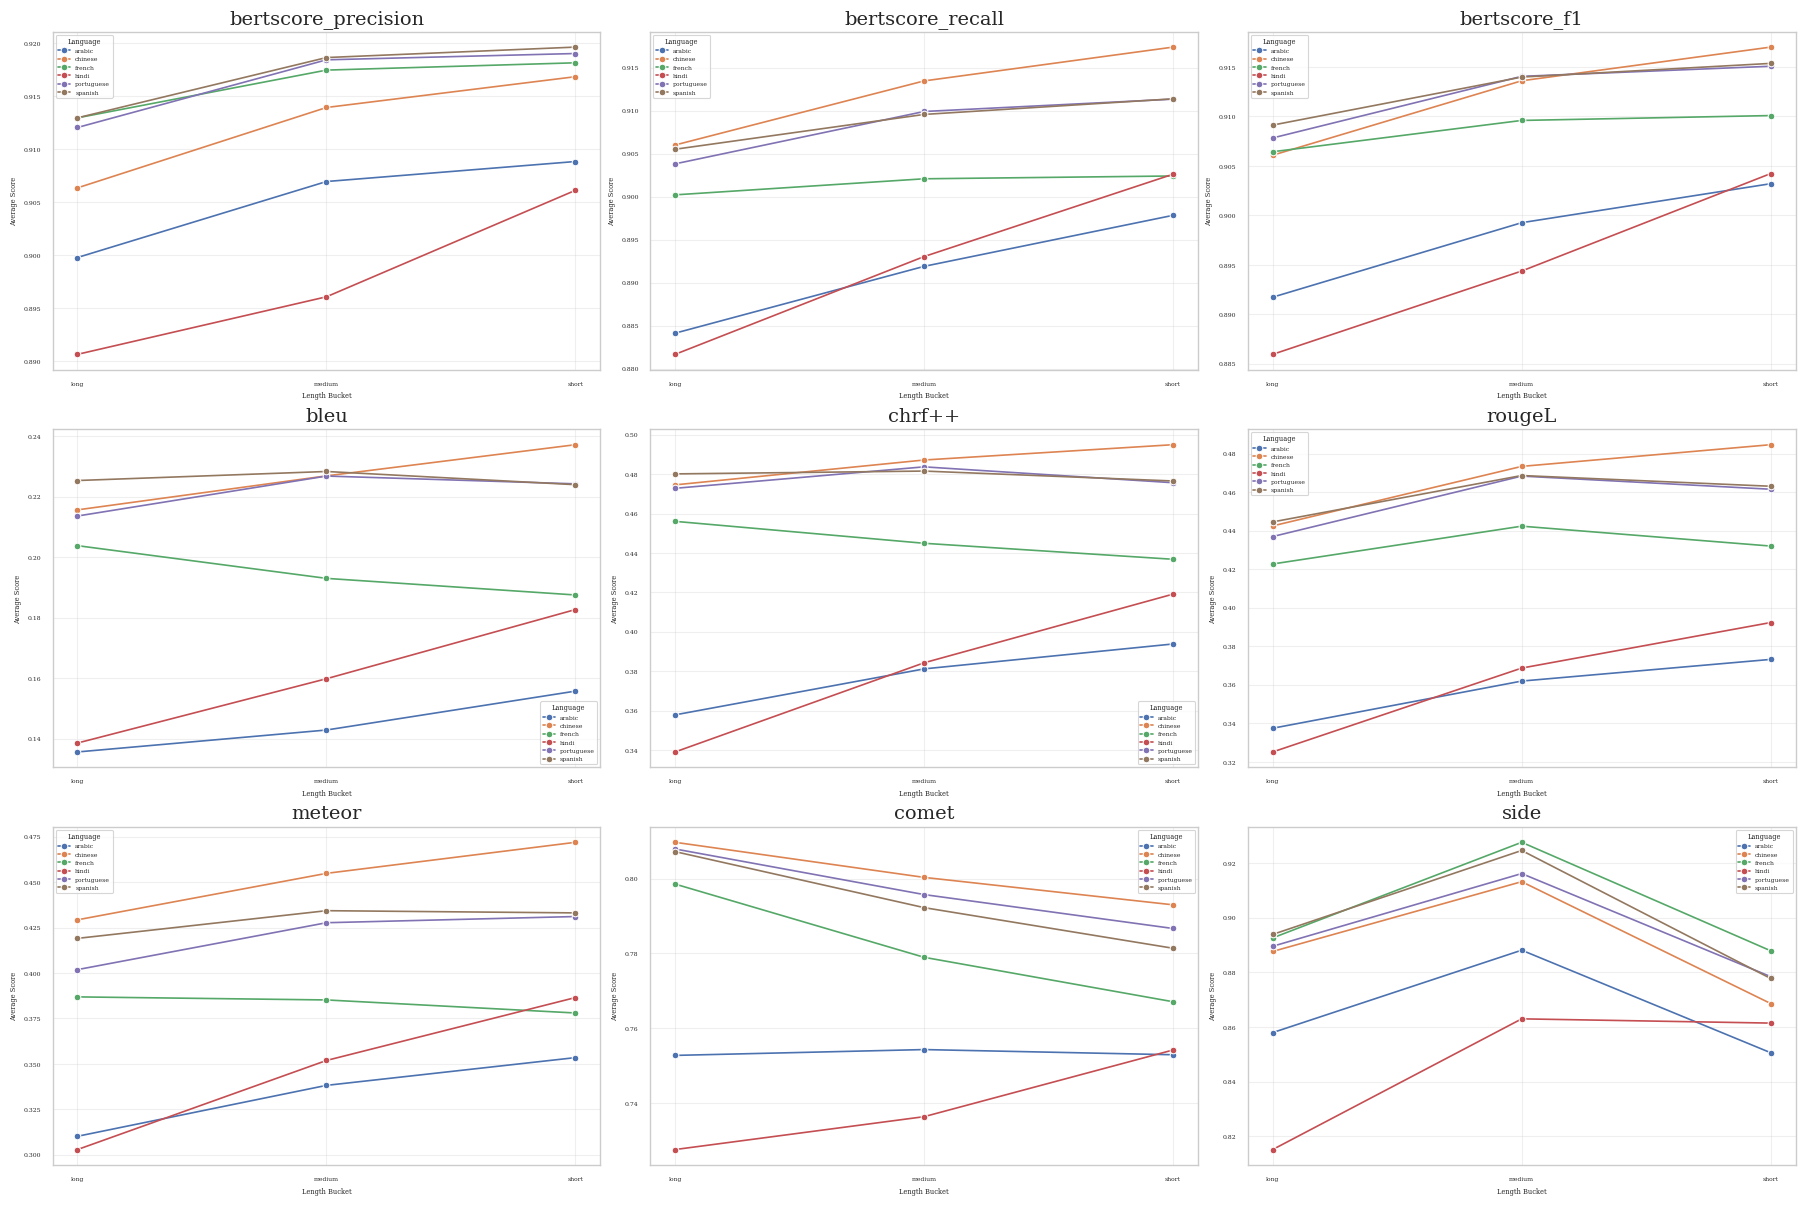

In [46]:


fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    sns.lineplot(
        data=avg_scores,
        x='length_bucket',
        y=metric,
        hue='bt_language',
        marker='o',
        ax=axes[i]
    )
    axes[i].set_title(metric, fontsize=14)
    axes[i].legend(title='Language')
    axes[i].set_xlabel('Length Bucket')
    axes[i].set_ylabel('Average Score')
    axes[i].grid(True, alpha=0.3)


plt.tight_layout()
filename = os.path.join("figures", "nlxpl_buckets.png")
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()


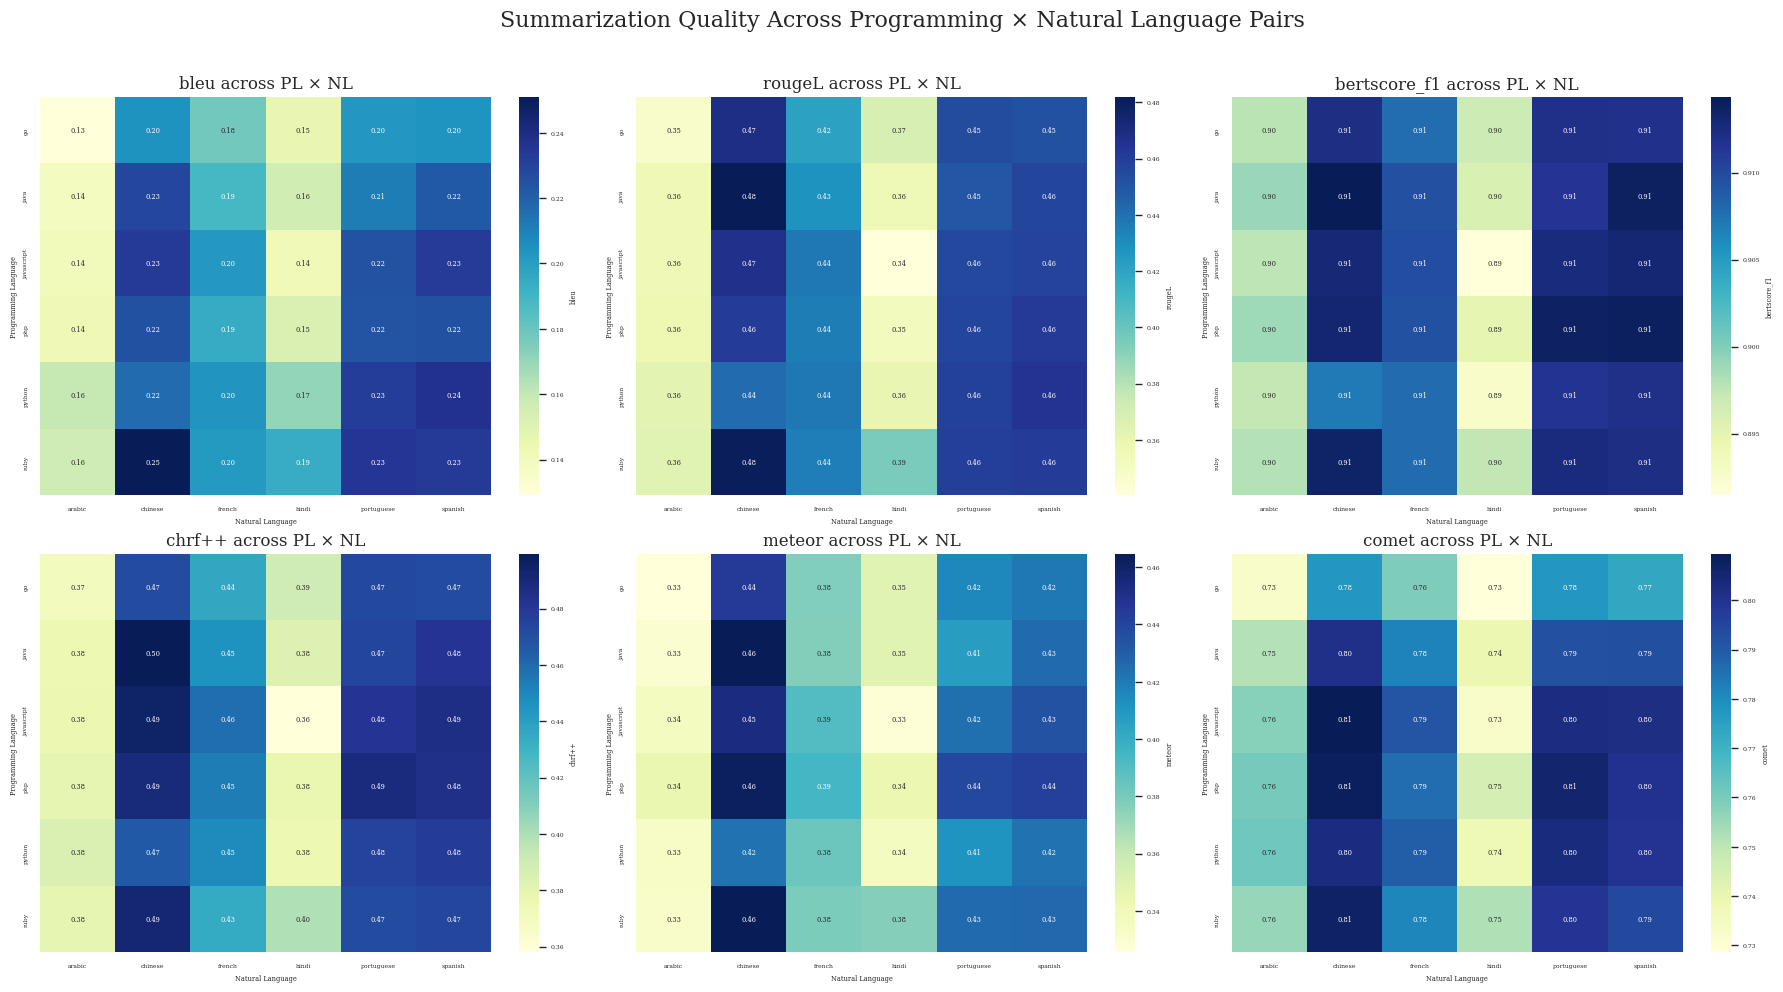

In [22]:
metrics = ["bleu", "rougeL", "bertscore_f1", "chrf++", "meteor", "comet"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    pivot = df.groupby(["programming_language", "bt_language"])[metric].mean().reset_index()
    pivot_table = pivot.pivot(index='programming_language', columns='bt_language', values=metric)

    sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[i], cbar_kws={'label': metric})
    axes[i].set_title(f"{metric} across PL × NL", fontsize=12)
    axes[i].set_xlabel("Natural Language")
    axes[i].set_ylabel("Programming Language")

plt.suptitle("Summarization Quality Across Programming × Natural Language Pairs", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [47]:
metrics = ['bertscore_f1',
           'bleu', 'chrf++', 'rougeL', 'meteor', 'comet', 'side']

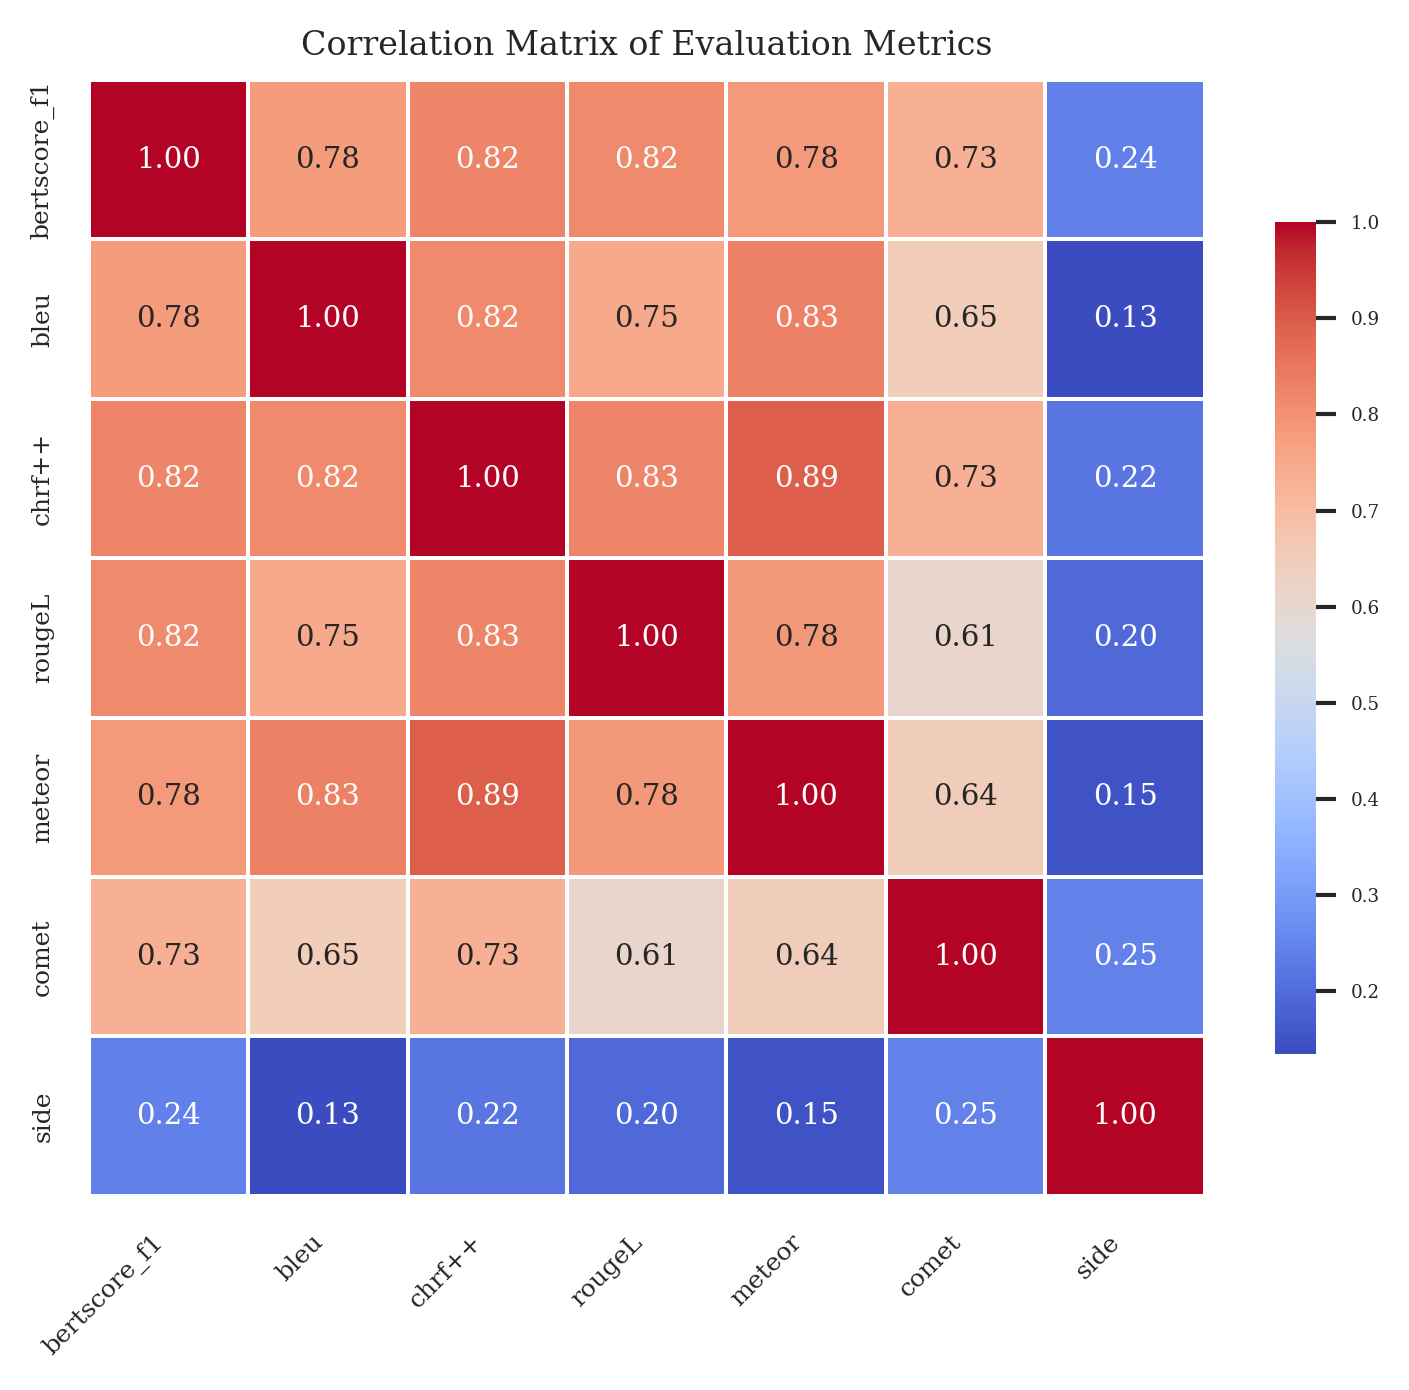

In [48]:

corr = df[metrics].corr()

# --- Plot ---
plt.figure(figsize=(6, 6), dpi=300)
heatmap = sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.6},
    annot_kws={"size": 7}
)

# --- Title and Layout ---
plt.title('Correlation Matrix of Evaluation Metrics', fontsize=8)
plt.xticks(rotation=45, ha='right', fontsize=6)
plt.yticks(fontsize=6)
filename = os.path.join("figures", "corr_eval_metrics.png")
plt.savefig(filename, dpi=400, bbox_inches='tight')


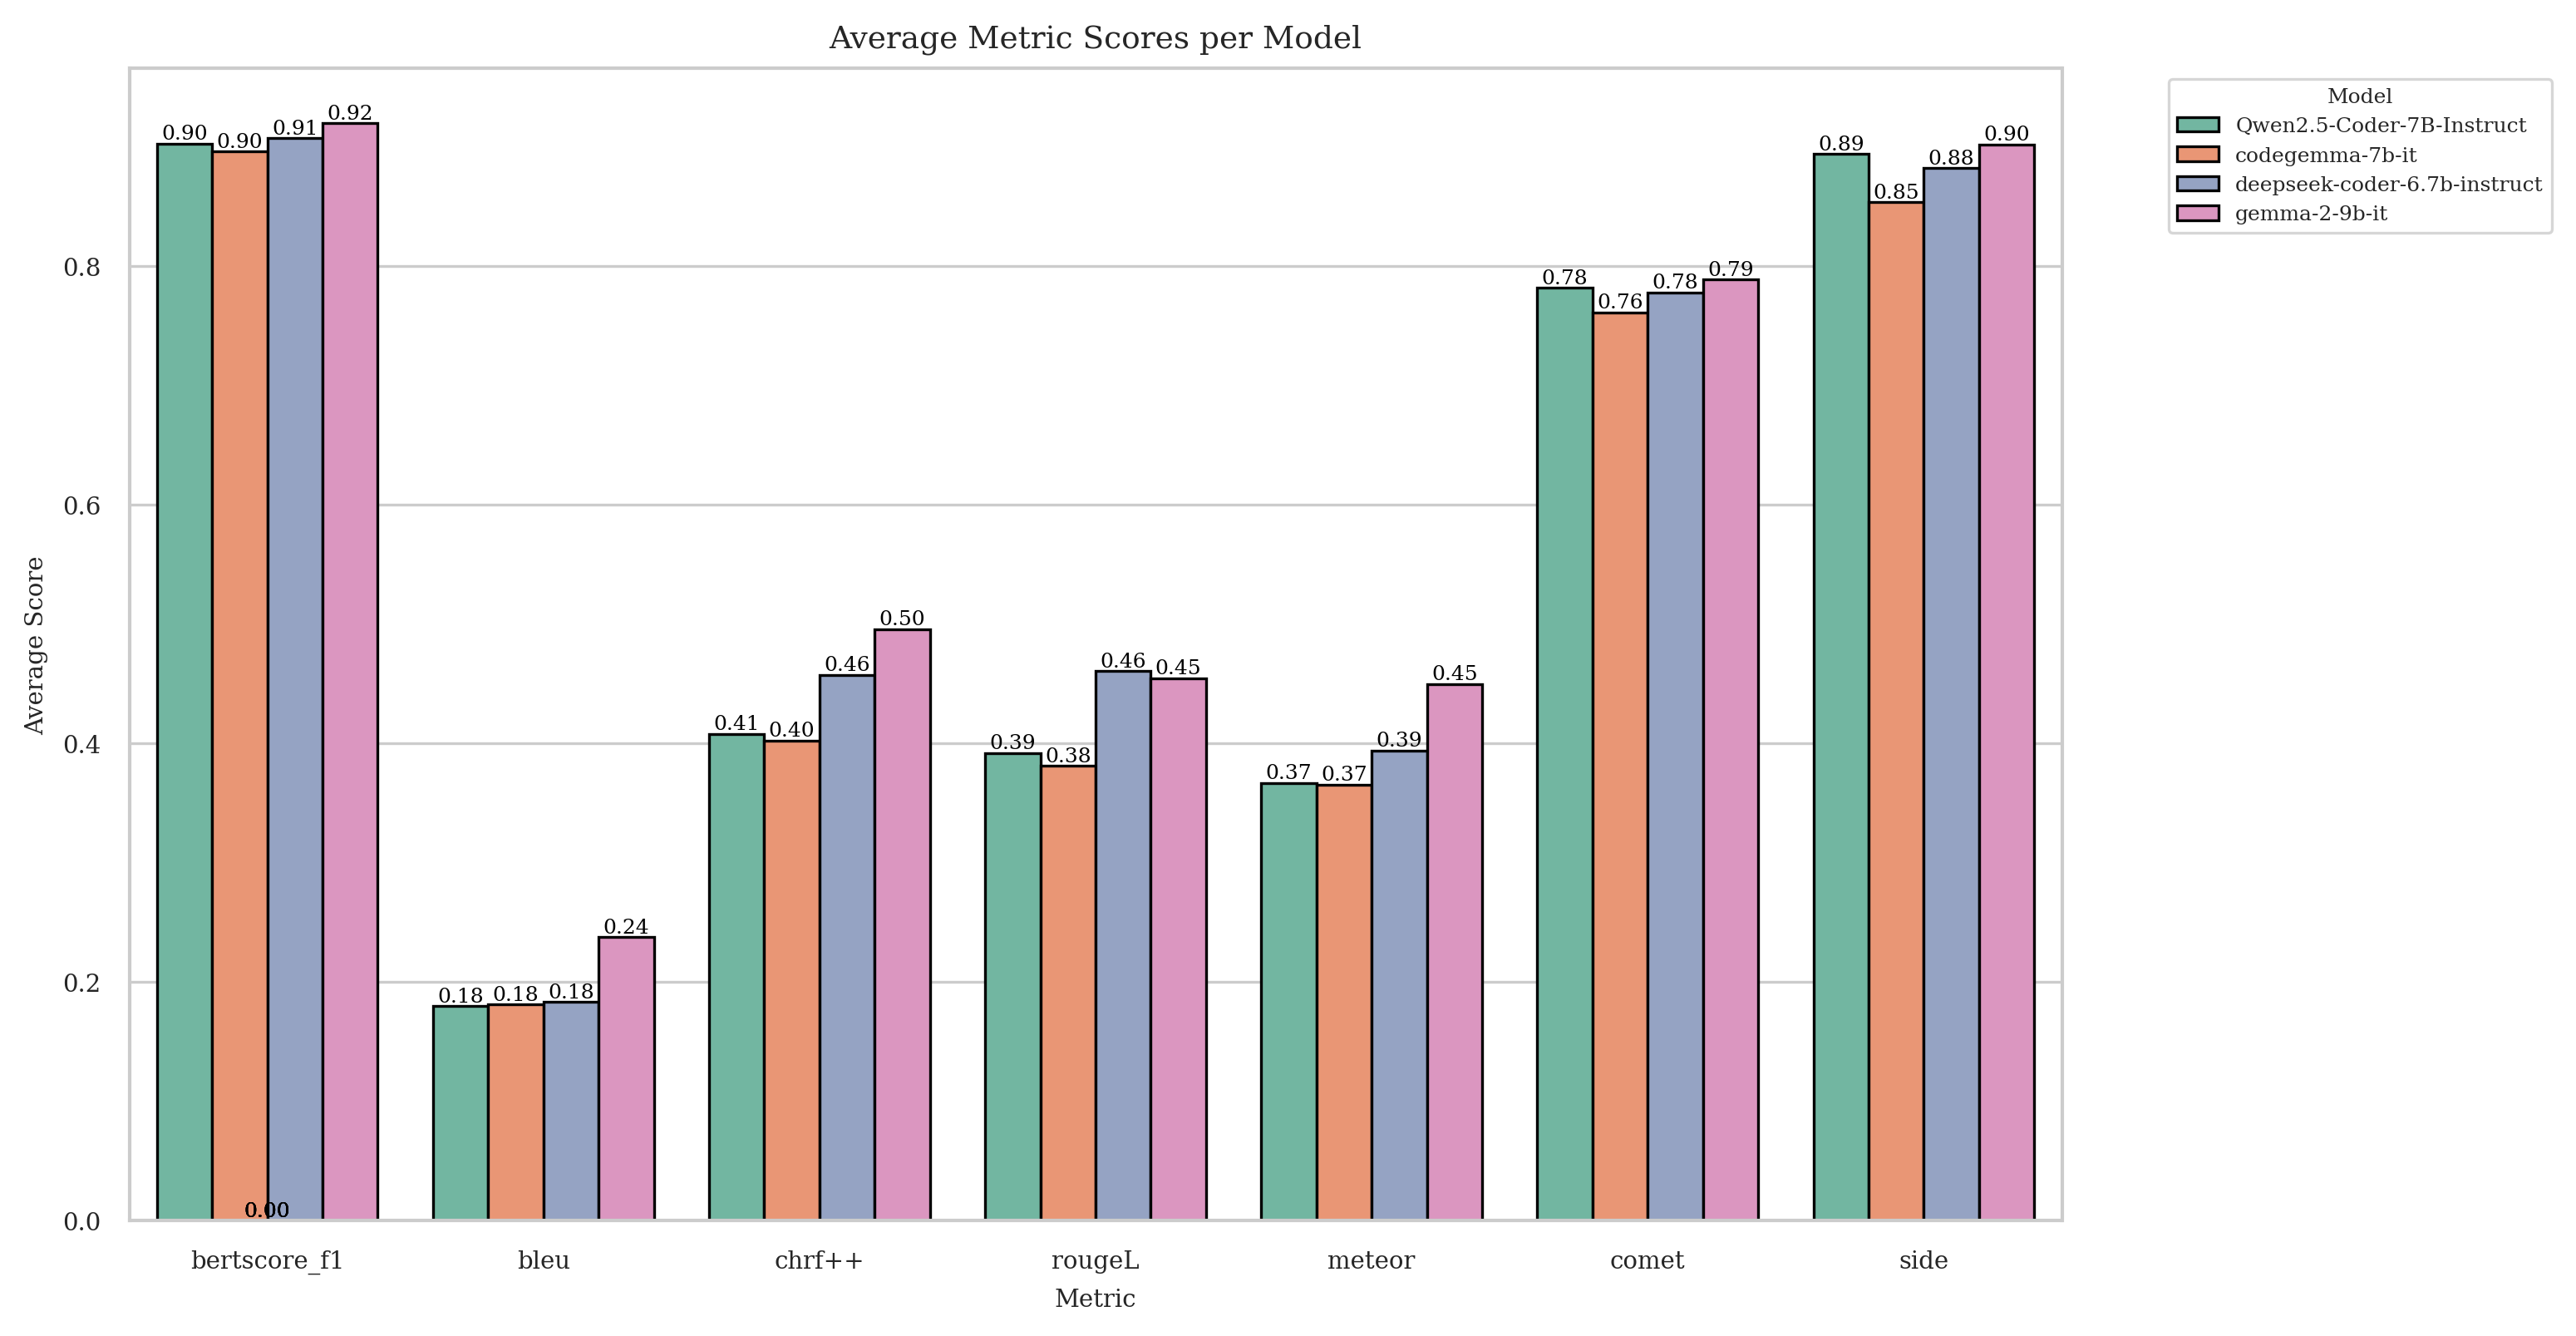

In [49]:
avg_scores = df.groupby('model_name')[metrics].mean().reset_index()

avg_melted = avg_scores.melt(
    id_vars='model_name',
    value_vars=metrics,
    var_name='Metric',
    value_name='Score'
)

# --- Plot ---
plt.figure(figsize=(10, 6), dpi=300)
ax = sns.barplot(
    data=avg_melted,
    x='Metric',
    y='Score',
    hue='model_name',
    palette='Set2',
    edgecolor='black'
)

# --- Annotate Bars ---
for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height):
        ax.annotate(f'{height:.2f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=6, color='black')

# --- Labels and Legend ---
ax.set_title('Average Metric Scores per Model', fontsize=9)
ax.set_ylabel('Average Score', fontsize=7)
ax.set_xlabel('Metric', fontsize=7)
ax.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6, title_fontsize=6)

plt.xticks(fontsize=7)
plt.yticks(fontsize=7)
filename = os.path.join("figures", "avg_metric_per_model.png")
plt.savefig(filename, dpi=300, bbox_inches='tight')


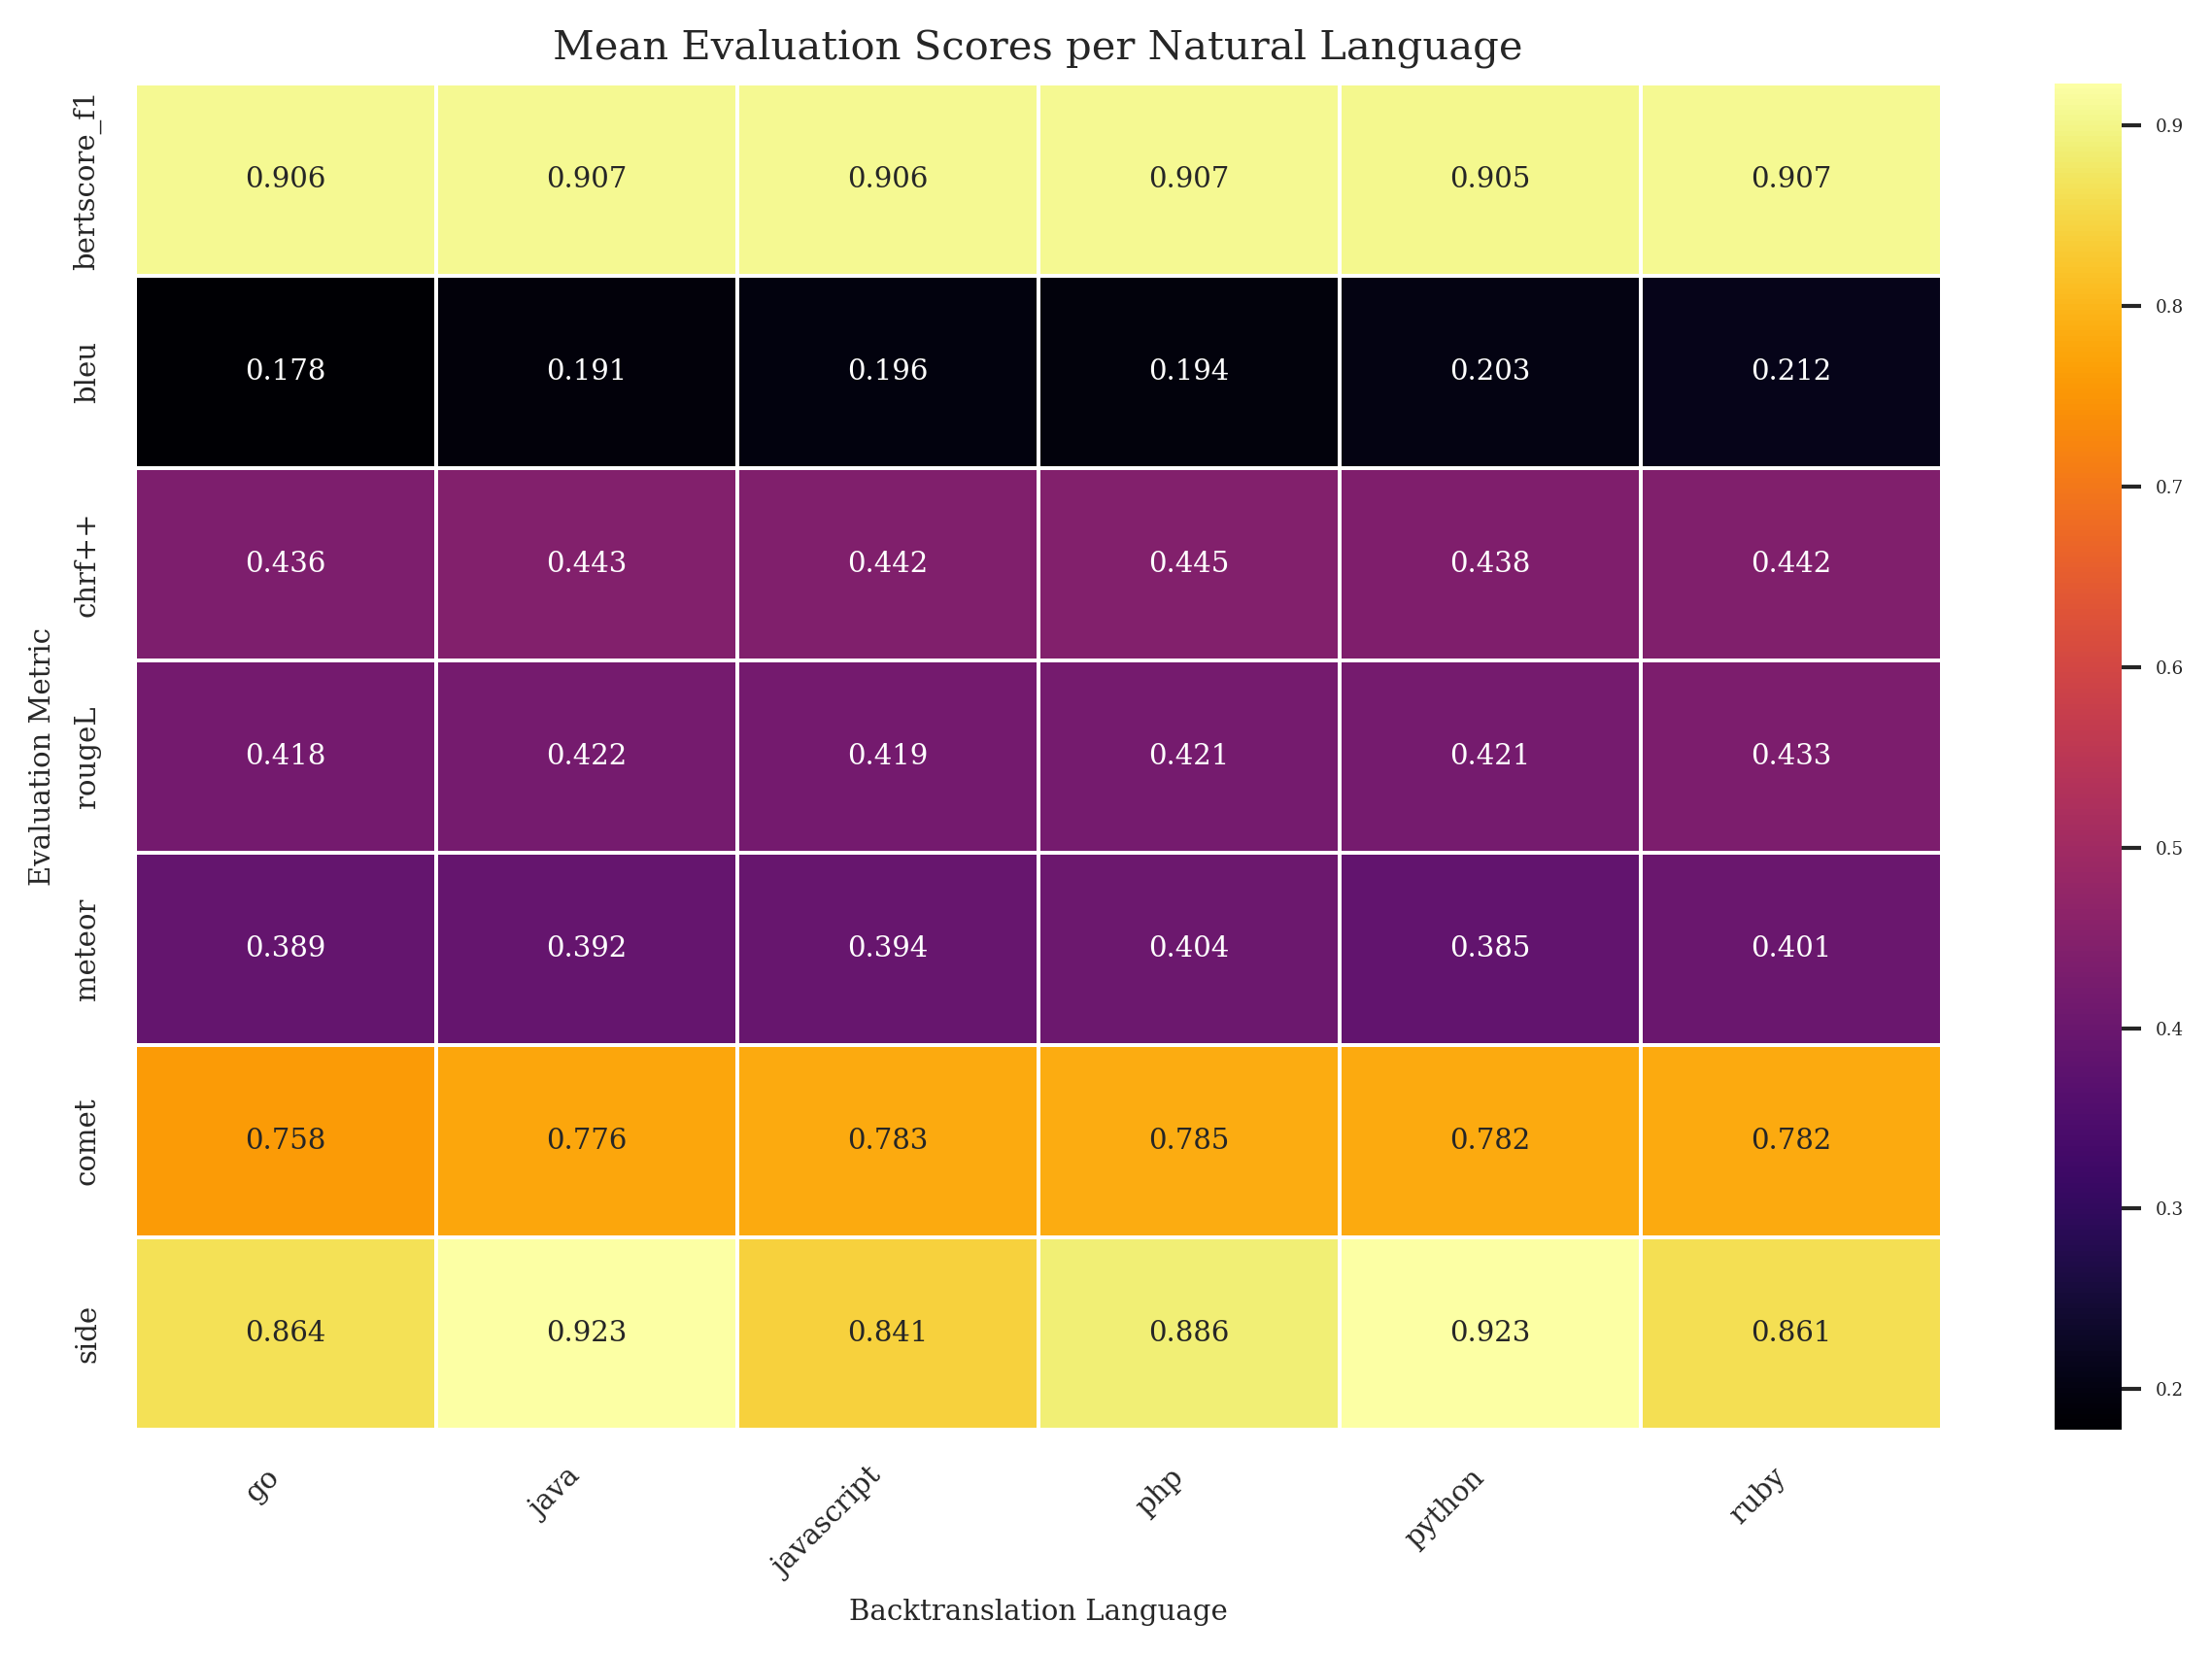

In [51]:

lang_metric_map = df.groupby('programming_language')[metrics].mean().T

# --- Plot ---
plt.figure(figsize=(10, 6), dpi=300)
sns.heatmap(
    lang_metric_map,
    annot=True,
    fmt=".3f",
    cmap='inferno',
    linewidths=0.5,
    annot_kws={"size": 7}
)

plt.title('Mean Evaluation Scores per Natural Language', fontsize=10)
plt.xlabel('Backtranslation Language', fontsize=7)
plt.ylabel('Evaluation Metric', fontsize=7)
plt.xticks(fontsize=7, rotation=45, ha='right')
plt.yticks(fontsize=7)
filename = os.path.join("figures", "mean_eval_per_nl.png")
plt.savefig(filename, dpi=400, bbox_inches='tight')


C:\Users\emann\AppData\Local\Temp\ipykernel_6904\397212248.py:23: UserWarning: The palette list has more values (8) than needed (7), which may not be intended.
  ax = sns.barplot(


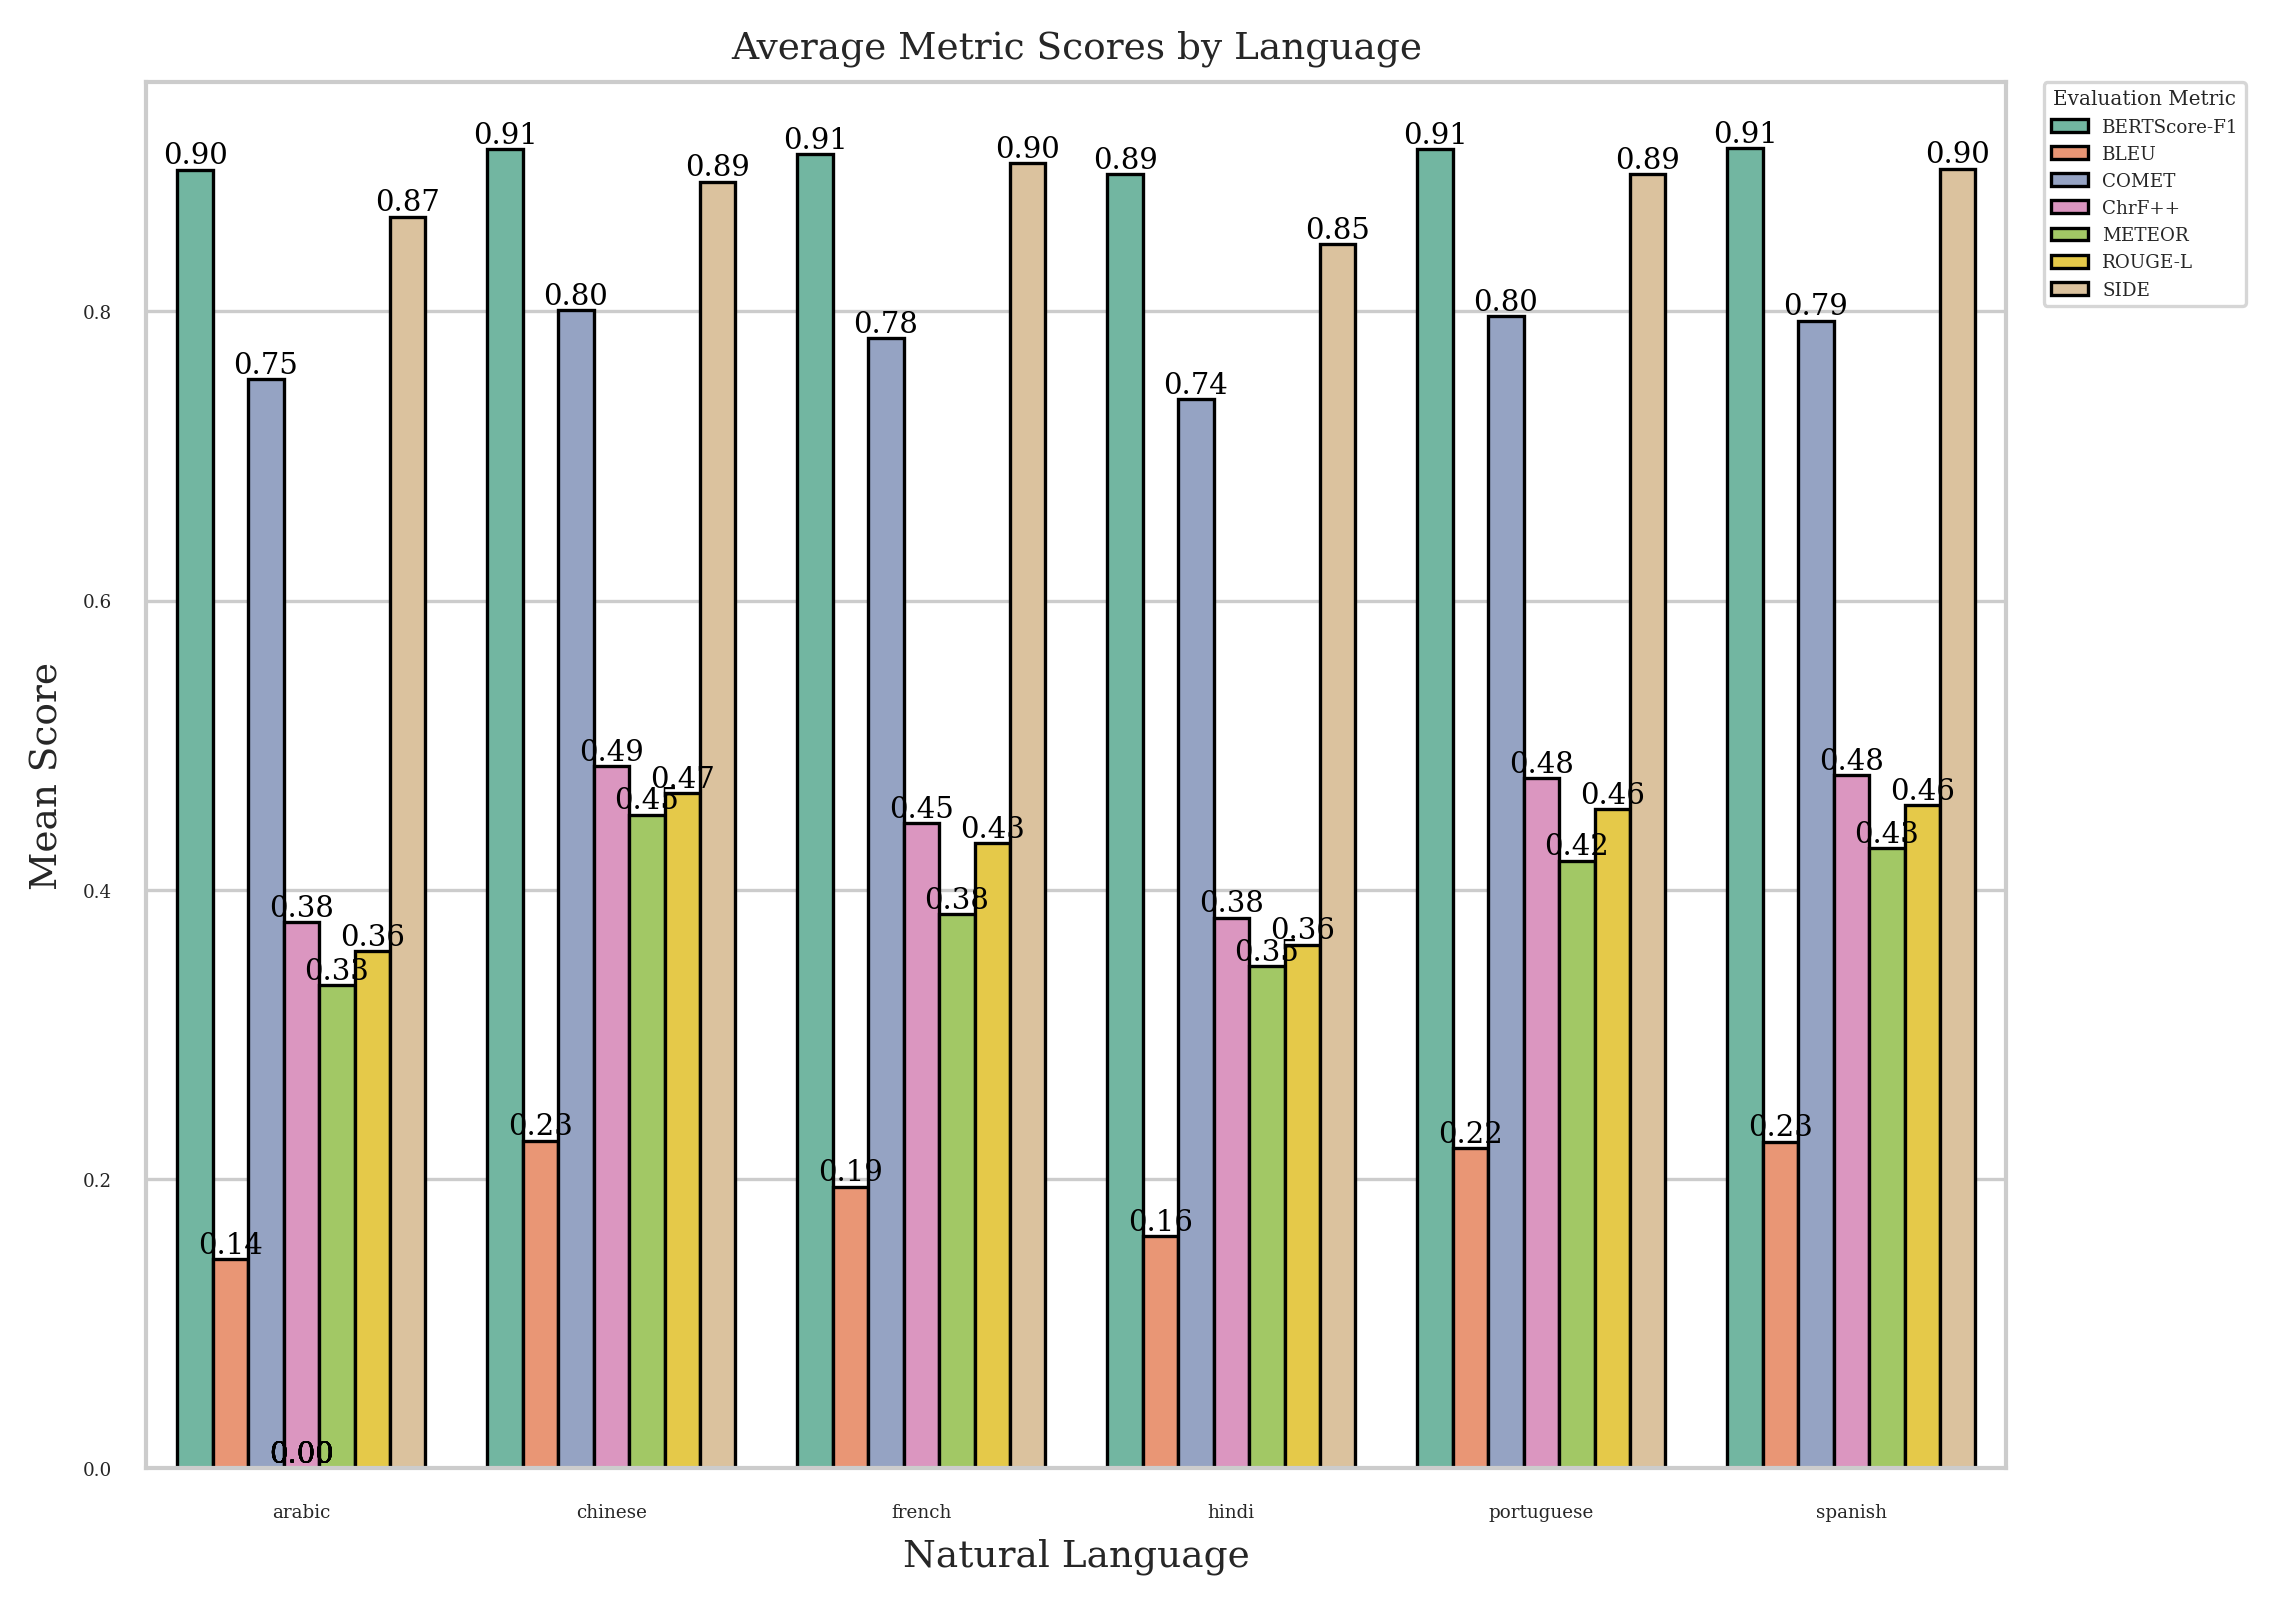

In [53]:
metric_cols = {
    'bertscore_f1': 'BERTScore-F1',
    'bleu': 'BLEU',
    'chrf++': 'ChrF++',
    'meteor': 'METEOR',
    'rougeL': 'ROUGE-L',
    'comet' : 'COMET',
    'side': 'SIDE'
}
df_melted = df.melt(
    id_vars=['bt_language'],
    value_vars=list(metric_cols.keys()),
    var_name='Metric',
    value_name='Score'
)
df_melted['Metric'] = df_melted['Metric'].map(metric_cols)
avg_scores = df_melted.groupby(['bt_language', 'Metric'], as_index=False)['Score'].mean()

# --- Plot ---
plt.figure(figsize=(8, 6), dpi=300)
custom_palette = sns.color_palette("Set2")

ax = sns.barplot(
    data=avg_scores,
    x='bt_language',
    y='Score',
    hue='Metric',
    palette=custom_palette,
    edgecolor='black'
)

# --- Annotate bars ---
for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height):
        ax.annotate(f'{height:.2f}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=7, color='black')

# --- Axis Labels and Title ---
ax.set_title("Average Metric Scores by Language", fontsize=9)
ax.set_xlabel("Natural Language", fontsize=9)
ax.set_ylabel("Mean Score", fontsize=9)

# --- Legend ---
ax.legend(title='Evaluation Metric', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
filename = os.path.join("figures", "avg_metric_by_language.png")
plt.savefig(filename, dpi=400, bbox_inches='tight')


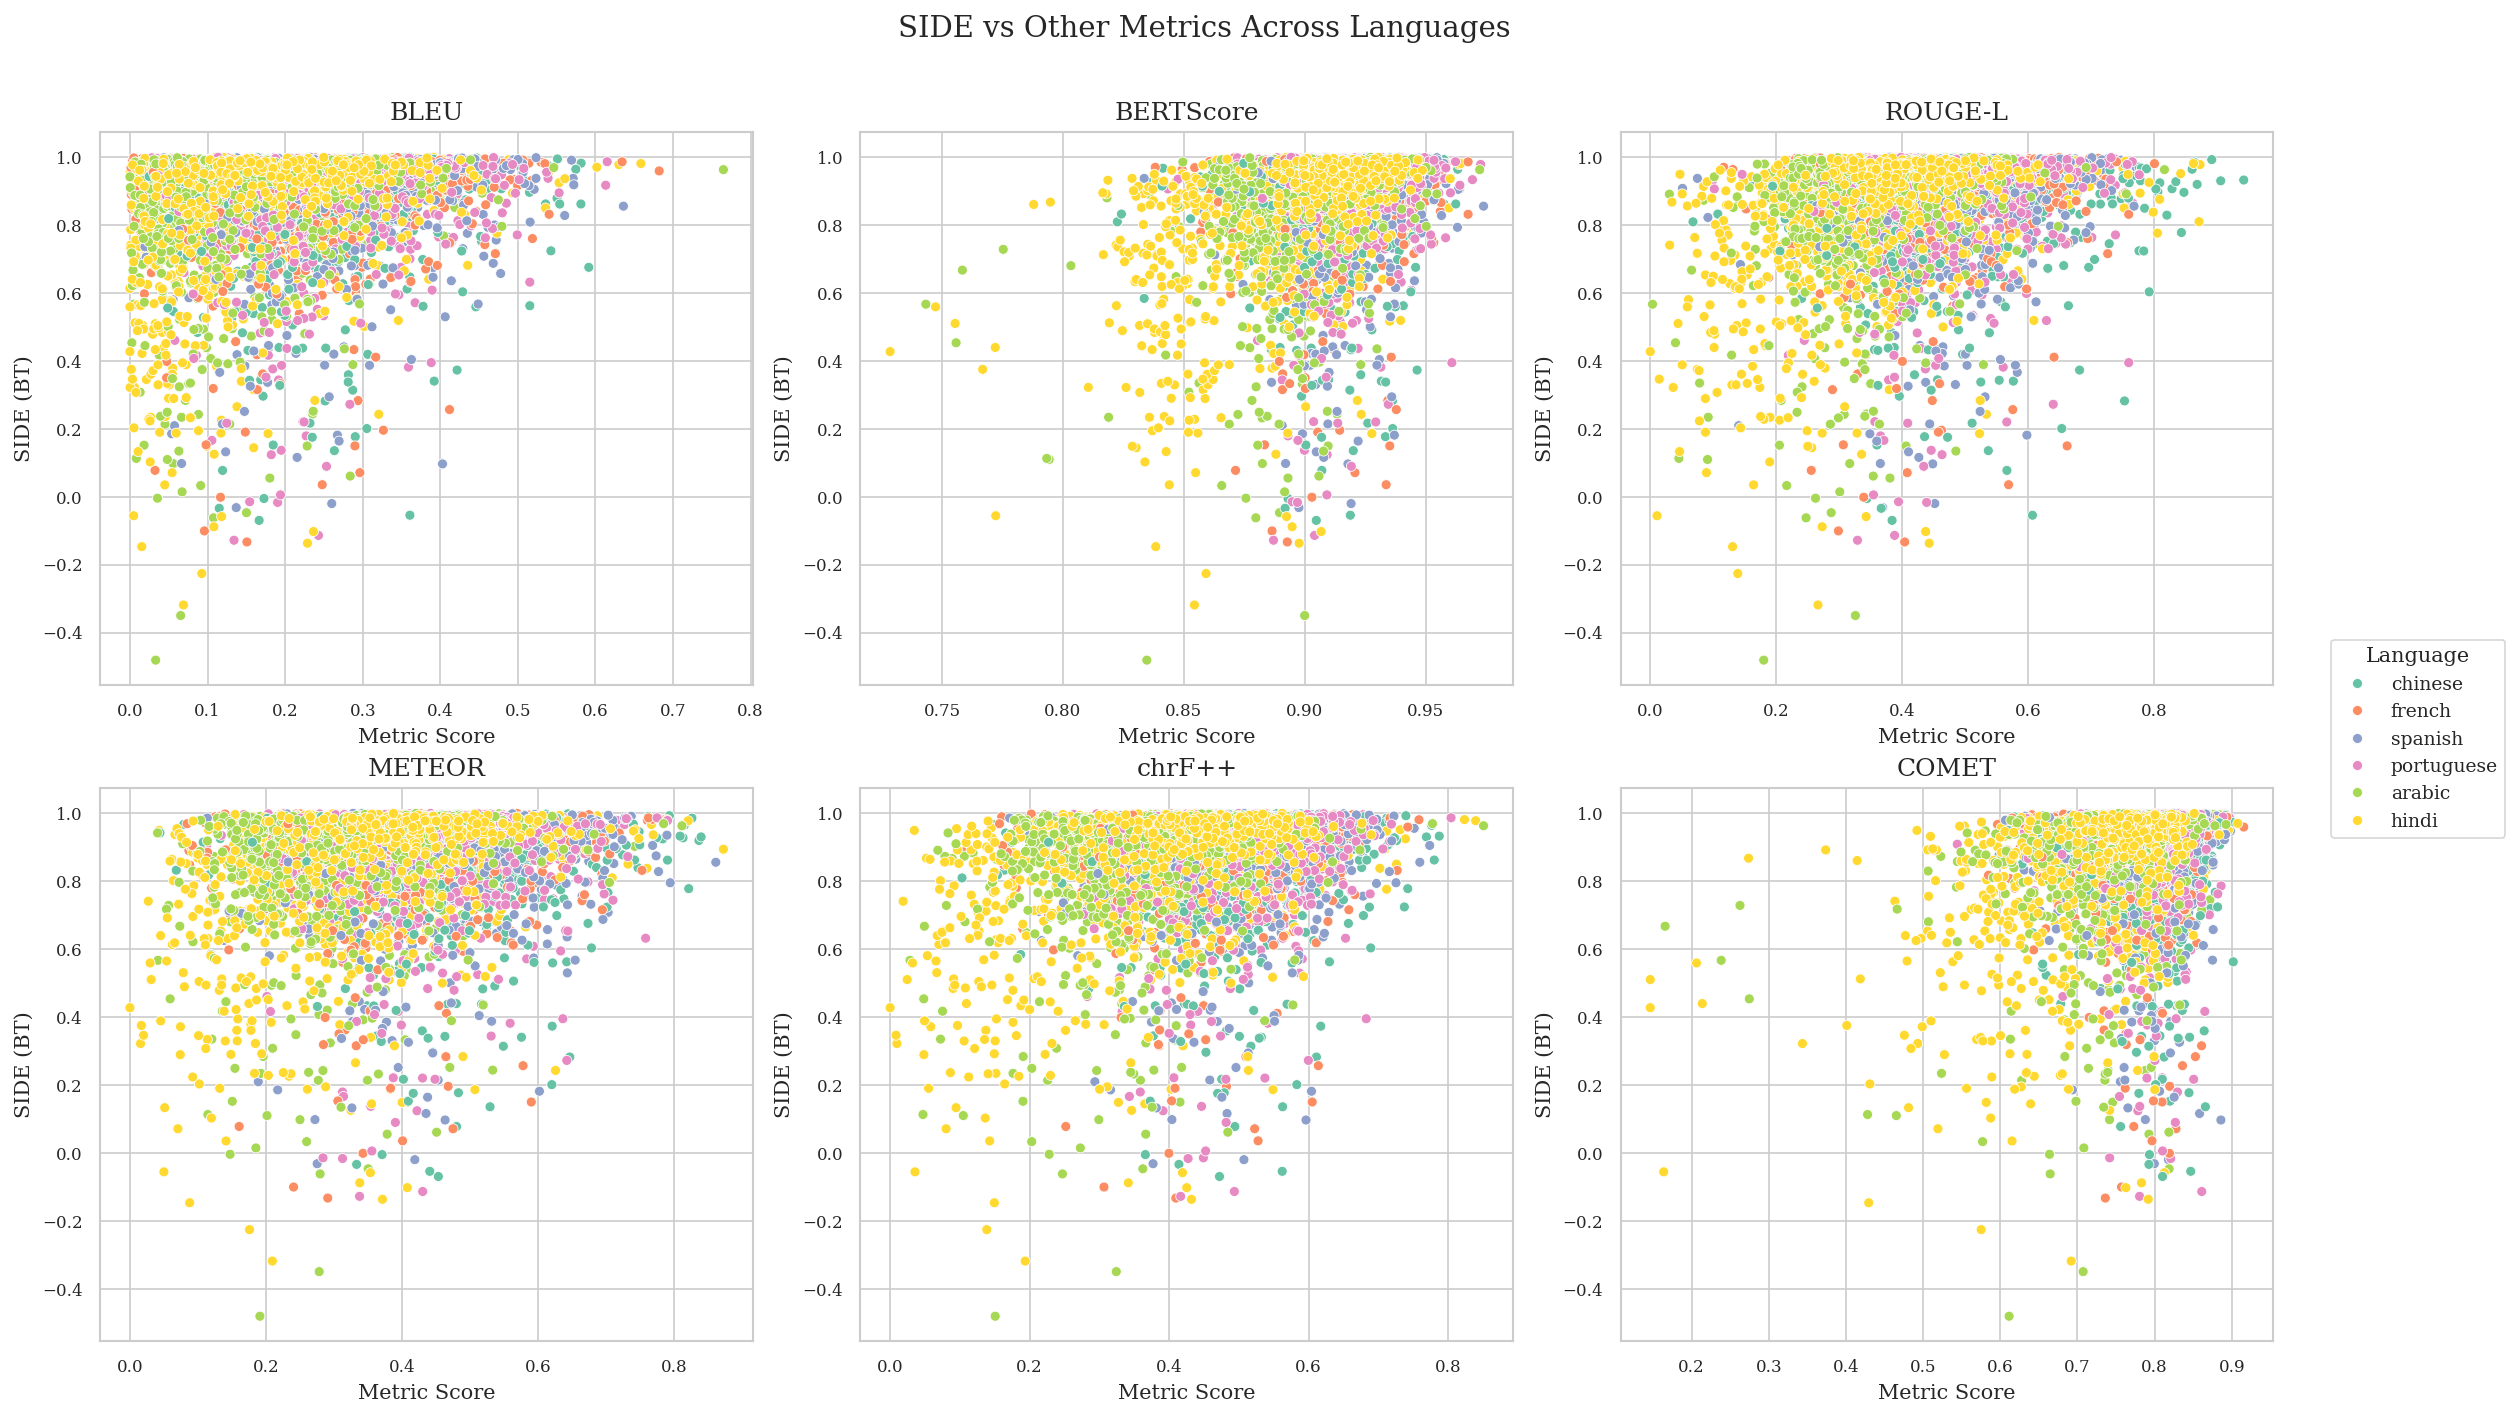

In [54]:

metrics = [
    ("bleu", "BLEU"),
    ("bertscore_f1", "BERTScore"),
    ("rougeL", "ROUGE-L"),
    ("meteor", "METEOR"),
    ("chrf++", "chrF++"),
    ("comet", "COMET")
]

fig, axs = plt.subplots(2, 3, figsize=(16, 9), dpi=150)
axs = axs.flatten()
for ax, (metric_col, metric_name) in zip(axs, metrics):
    sns.scatterplot(
        data=df,
        x=metric_col,
        y="side",
        hue="bt_language",
        ax=ax,
        palette="Set2"
    )
    ax.set_title(metric_name, fontsize=12)
    ax.set_xlabel("Metric Score", fontsize=10)
    ax.set_ylabel("SIDE (BT)", fontsize=10)
    ax.tick_params(labelsize=8)
    legend = ax.get_legend()
    if legend:
        legend.remove()  # remove individual legends

handles, labels = axs[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title='Language',
    title_fontsize=10,
    fontsize=9,
    loc='center right',
    bbox_to_anchor=(1.05, 0.5),
    borderaxespad=1.0
)

fig.text(0.5, 1.02, "SIDE vs Other Metrics Across Languages", ha='center', fontsize=14)
plt.tight_layout(rect=[0, 0, 0.95, 0.98])
filename = os.path.join("figures", "side_vs_metrics.png")
plt.savefig(filename, dpi=400, bbox_inches='tight')